In [11]:
import tensorflow as tf
import numpy as np

## Load Dataset dan Lihat Bentuk Dataset

In [13]:
data = np.load("../../Datasets/mnist.npz")

X_train = data["x_train"]
y_train = data["y_train"]

X_test = data["x_test"]
y_test = data["y_test"]

print(X_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


## Normalisasi

In [14]:
X_train = X_train / 255.0
X_test = X_test / 255.0

## Tambahkan Channel

In [15]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print(X_train.shape)

(60000, 28, 28, 1)


## Membuat Model CNN

In [16]:
model = tf.keras.Sequential()

## Layer 1 — Convolution

In [ ]:
model.add(
    tf.keras.layers.Conv2D(
        filters=32, # membuat 32 kernel
        kernel_size=(3,3), # ukuran kernel 3*3
        activation="relu", # activationnya adalah relu
        input_shape=(28,28,1)
    )
)

## Layer 2 — Max Pooling

In [17]:
model.add(
    tf.keras.layers.MaxPooling2D(pool_size=(2,2))
)

## Layer 3 — Convolution 

In [18]:
model.add(
    tf.keras.layers.Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation="relu"
    )
)

## Layer 4 — Max Pooling lagi

In [19]:
model.add(
    tf.keras.layers.MaxPooling2D(pool_size=(2,2))
)

## Layer 5 — Flatten

In [20]:
model.add(
    tf.keras.layers.Flatten()
)

## Layer 6 — Dense

In [21]:
model.add(
    tf.keras.layers.Dense(
        128,
        activation="relu"
    )
)

## Layer Output

In [22]:
# Karena MNIST memiliki 10 kelas (0–9).

model.add(
    tf.keras.layers.Dense(
        10,
        activation="softmax"
    )
)

## Compile

In [23]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Training

In [33]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9984 - loss: 0.0054 - val_accuracy: 0.9848 - val_loss: 0.0720
Epoch 2/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9981 - loss: 0.0056 - val_accuracy: 0.9833 - val_loss: 0.0828
Epoch 3/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9984 - loss: 0.0049 - val_accuracy: 0.9883 - val_loss: 0.0683
Epoch 4/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9983 - loss: 0.0047 - val_accuracy: 0.9852 - val_loss: 0.0810
Epoch 5/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9987 - loss: 0.0036 - val_accuracy: 0.9857 - val_loss: 0.0816
Epoch 6/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9987 - loss: 0.0037 - val_accuracy: 0.9877 - val_loss: 0.0740


## Evaluasi

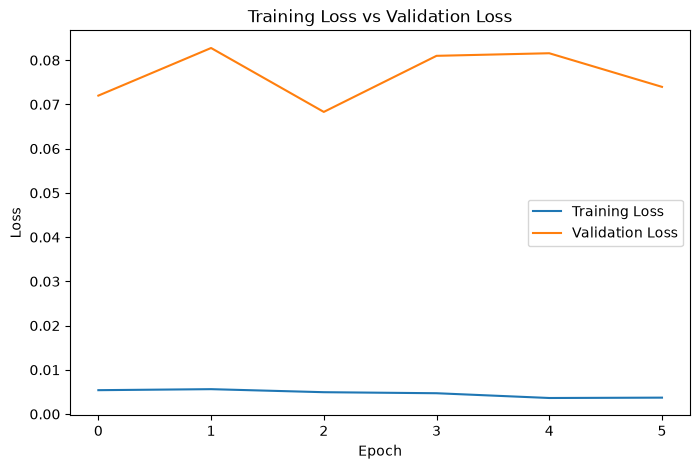

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training Loss vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

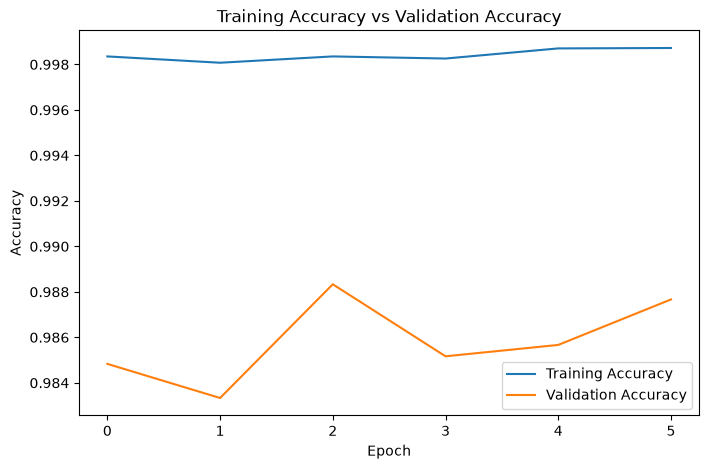

In [35]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training Accuracy vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## Predict

In [36]:
prediction = model.predict(X_test[:1])

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
[[1.4526109e-17 2.8869890e-17 5.3194737e-13 2.0571073e-14 6.4235331e-19
  1.0445028e-15 5.1962601e-20 1.0000000e+00 7.3743298e-15 3.2894889e-13]]


In [37]:
predicted_label = np.argmax(prediction)

print(predicted_label)

7


In [38]:
print("Prediksi :", predicted_label)
print("Label Asli :", y_test[0])

Prediksi : 7
Label Asli : 7


## Menampilkan Gambar

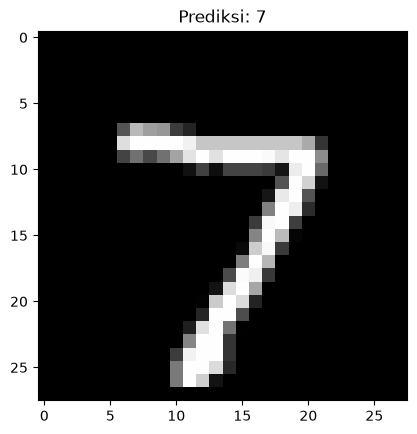

In [39]:
import matplotlib.pyplot as plt

plt.imshow(X_test[0].reshape(28,28), cmap="gray")
plt.title(f"Prediksi: {predicted_label}")
plt.show()